In [5]:
import numpy as np
import seaborn as sns
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
import pandas as pd




In [8]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


IQR for 'AveRooms': 1.61
Lower Bound: 2.02
Upper Bound: 8.47
Number of rows in the dataset: 20640
Number of outliers in 'AveRooms': 511


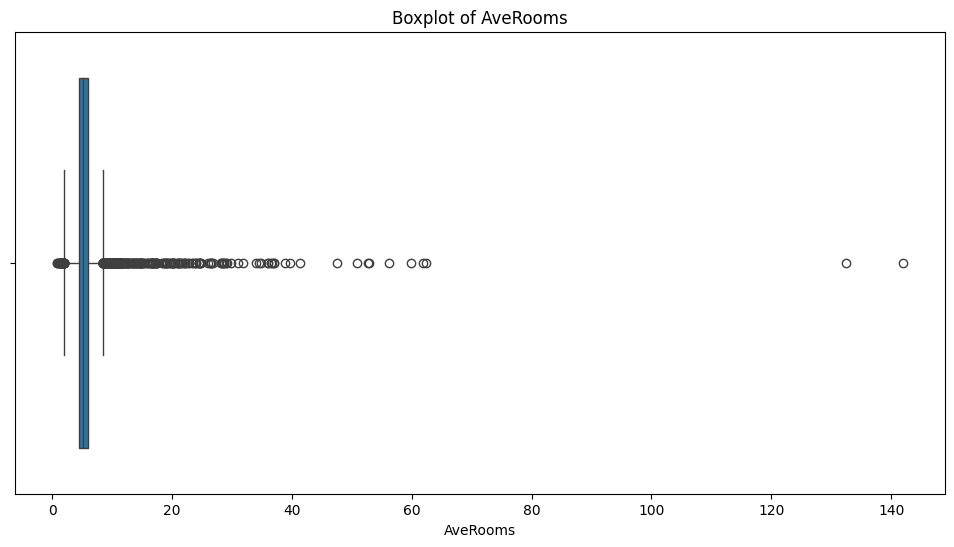

In [15]:
column = 'AveRooms'
q1 = df[column].quantile(0.25)
q3 = df[column].quantile(0.75)
# calculate the interquartile range (IQR)
iqr = q3 - q1
print(f"IQR for '{column}': {iqr:.2f}")
# calculate the lower and upper bounds for outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
# calculate the number of outliers
outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print(f"Number of rows in the dataset: {len(df)}")
print(f"Number of outliers in '{column}': {len(outliers)}")

# visualize the distribution of the column
plt.figure(figsize=(12, 6)) #12 inches wide and 6 inches tall for canvas
sns.boxplot(x=df[column])
plt.title(f"Boxplot of {column}")
plt.show()
# sns.histplot(df[column], kde=True)

In [19]:
# clean the outliers by replacing them with the median value of the column
df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
print(f"Shape of the original dataset: {df.shape}") 
print(f"Shape of the cleaned dataset: {df_cleaned.shape}")

Shape of the original dataset: (20640, 8)
Shape of the cleaned dataset: (20129, 8)


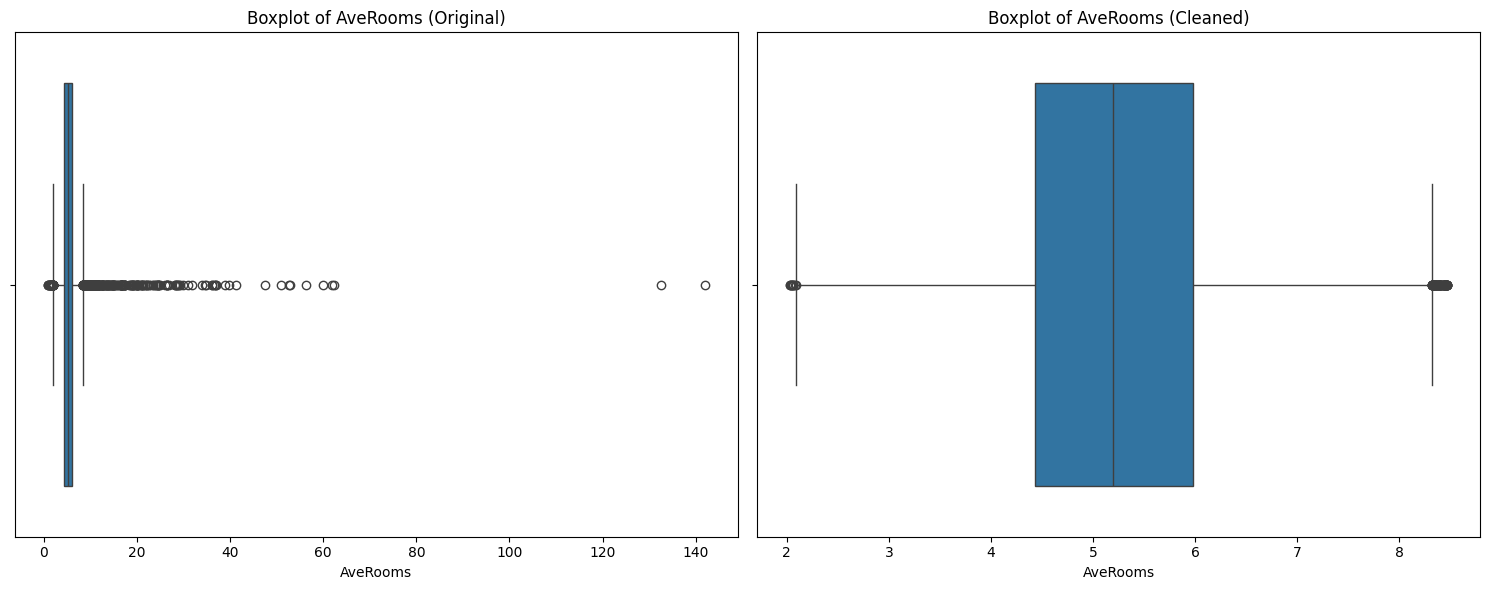

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))#1 row, 2 columns, 15 inches wide and 6 inches tall for canvas
sns.boxplot(x=df[column], ax=ax[0])
ax[0].set_title(f"Boxplot of {column} (Original)")
sns.boxplot(x=df_cleaned[column], ax=ax[1])
ax[1].set_title(f"Boxplot of {column} (Cleaned)")
plt.tight_layout()
plt.show()



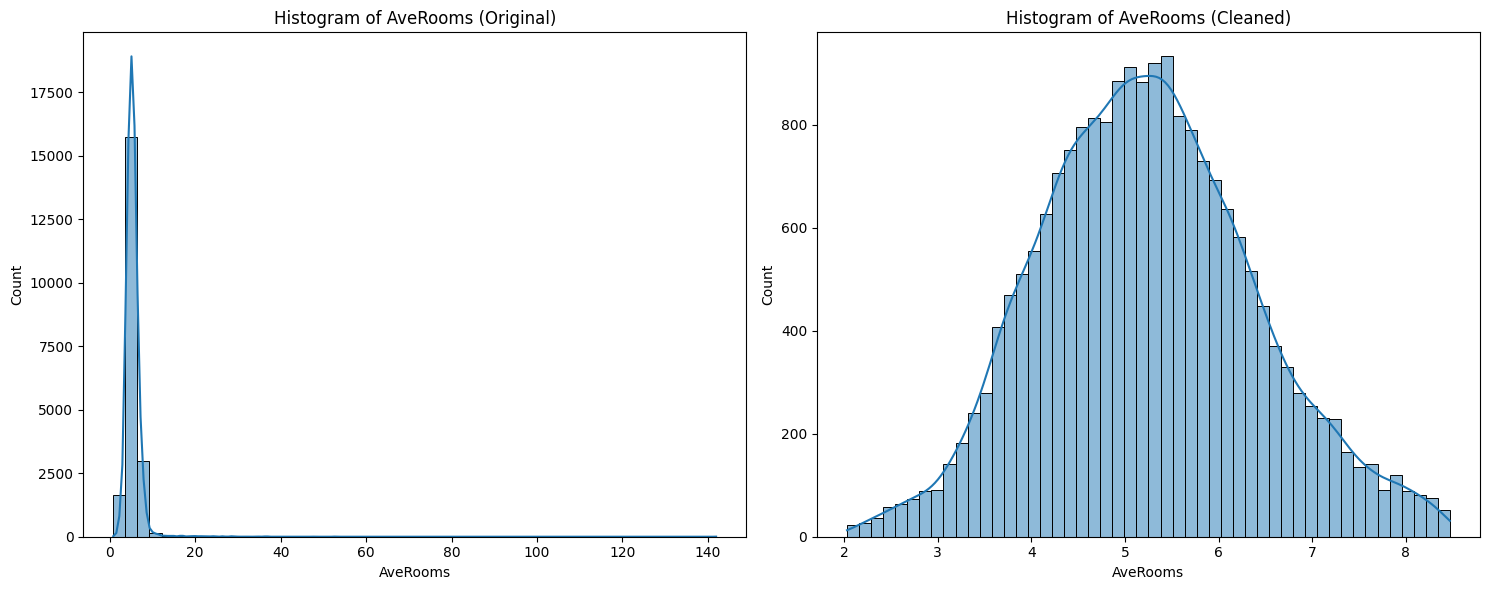

In [28]:
# visualize the distribution of the column before and after cleaning
fig, ax = plt.subplots(1, 2, figsize=(15, 6))#1 row, 2 columns, 15 inches wide and 6 inches tall for canvas
sns.histplot(df[column], bins = 50 , ax=ax[0],kde =True)#50 bins for the histogram and kde=True to add a kernel density estimate to the plot
ax[0].set_title(f"Histogram of {column} (Original)")
sns.histplot(df_cleaned[column], bins = 50 , ax=ax[1],kde =True)
ax[1].set_title(f"Histogram of {column} (Cleaned)")
plt.tight_layout()
plt.show()

In [29]:
column1 = 'AveBedrms'
#calculate the IQR for the column
q1 = df[column1].quantile(0.25)
q3 = df[column1].quantile(0.75)
iqr = q3 - q1
print(f"IQR for '{column1}': {iqr:.2f}")
# calculate the lower and upper bounds for outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
# calculate the number of outliers
outliers = df[(df[column1] < lower_bound) | (df[column1] > upper_bound)]
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print(f"Number of rows in the dataset: {len(df)}")
print(f"Number of outliers in '{column1}': {len(outliers)}")


IQR for 'AveBedrms': 0.09
Lower Bound: 0.87
Upper Bound: 1.24
Number of rows in the dataset: 20640
Number of outliers in 'AveBedrms': 1424


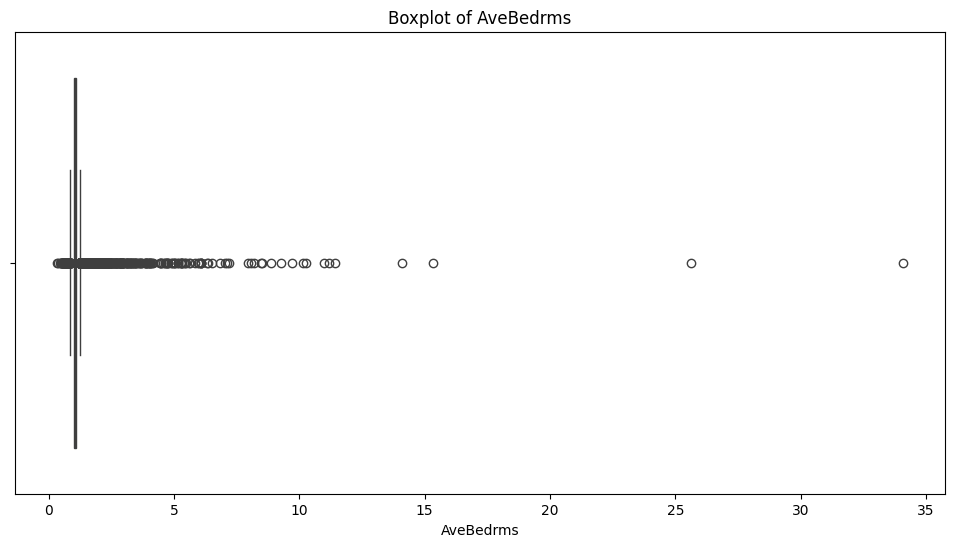

In [30]:
# visualize the distribution of the column
plt.figure(figsize=(12, 6)) #12 inches wide and 6 inches tall for
sns.boxplot(x=df[column1])
plt.title(f"Boxplot of {column1}")
plt.show()


Shape of the original dataset: (20640, 8)
Shape of the cleaned dataset: (19216, 8)


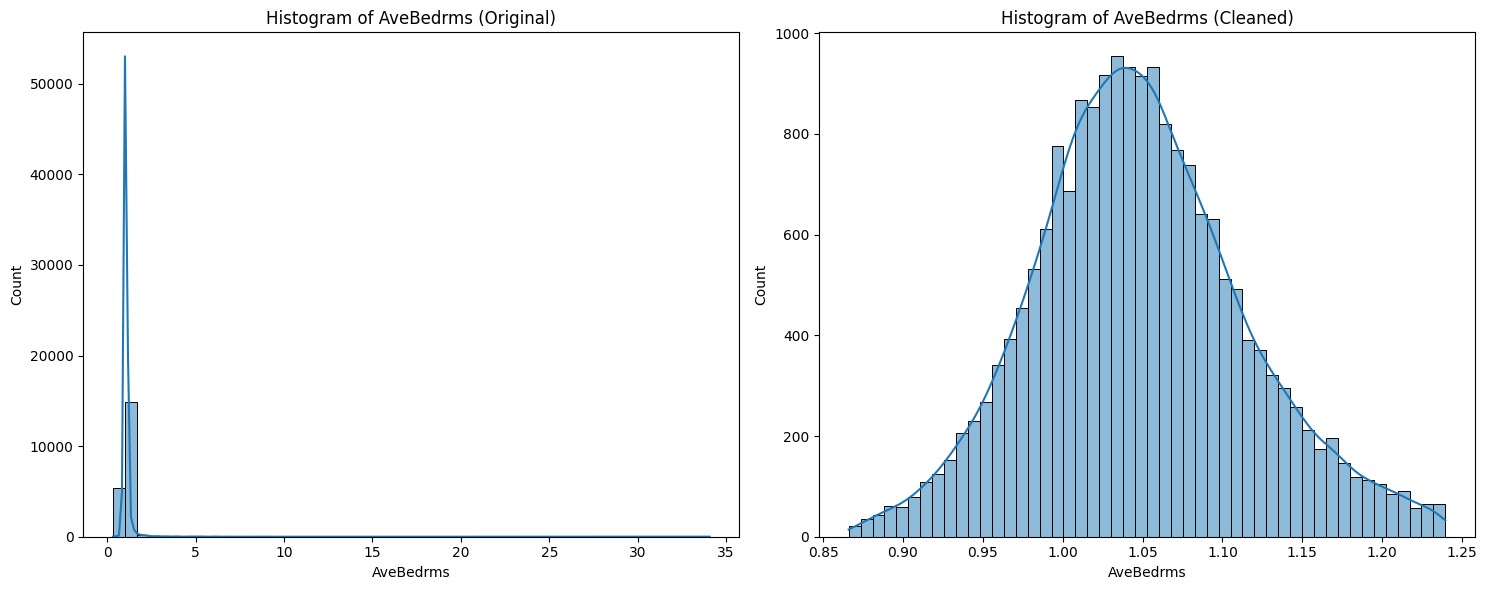

In [40]:
#clean the outliers by replacing them with the median value of the column
df_cleaned = df[(df[column1] >= lower_bound) & (df[column1] <= upper_bound)]
print(f"Shape of the original dataset: {df.shape}")
print(f"Shape of the cleaned dataset: {df_cleaned.shape}")
# visualize the distribution of the column before and after cleaning
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(df[column1], bins = 50, ax=ax[0],kde =True)
ax[0].set_title(f"Histogram of {column1} (Original)")
sns.histplot(df_cleaned[column1], bins = 50, ax=ax[1],kde =True)
ax[1].set_title(f"Histogram of {column1} (Cleaned)")


plt.tight_layout()
plt.show()
